Источник: [Vision Transformers Explained Series](https://github.com/lanl/vision_transformers_explained/tree/main)

# Position Embeddings для Vision Transformers

С момента своего появления в 2017 году с проектом Attention is All You Need, трансформеры зарекомендовали себя как передовой инструмент обработки естественного языка (NLP). В 2021 году проект An Image is Worth 16x16 Words успешно адаптировал трансформеры для задач компьютерного зрения. С тех пор было предложено множество архитектур на основе трансформеров для решения задач, связанных с компьютерным зрением.

В этой статье рассматривается, почему позиционные эмбеддинги являются необходимым компонентом трансформеров для компьютерного зрения, и как в различных работах реализованы позиционные эмбеддинги, на основе открытого исходного кода для позиционных эмбеддингов. Весь код использует пакет PyTorch Python.

Все статьи из серии:

 - [Vision Transformers, Explained](https://towardsdatascience.com/vision-transformers-explained-a9d07147e4c8)
    - [Jupyter Notebook](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/VisionTransformersExplained.ipynb)
 - [Attention for Vision Transformers, Explained](https://towardsdatascience.com/attention-for-vision-transformers-explained-70f83984c673)
    - [Jupyter Notebook](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/AttentionExplained.ipynb)
 - [Position Embeddings for Vision Transformers, Explained](https://towardsdatascience.com/position-embeddings-for-vision-transformers-explained-a6f9add341d5)
    - [**Jupyter Notebook**](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/PositionEmbeddingExplained.ipynb)
 - [Tokens-to-Token Vision Transformers, Explained](https://towardsdatascience.com/tokens-to-token-vision-transformers-explained-2fa4e2002daa)
    - [Jupyter Notebook](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/TokensToTokenViTExplained.ipynb)
 - [GitHub Repository](https://github.com/lanl/vision_transformers_explained) for Vision Transformers, Explained Series

In [ ]:
import os
import copy
import math
import typing
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch

# Почему используется позиционное кодирование?

В статье "Attention is All You Need" постулируется, что трансформеры не в состоянии ввыучивать информацию о порядке следования токенов в последовательности, поскольку они не содержат рекуррентных или свёрточных слоёв. Без позиционных эмбеддингов (position embedding), трансформеры инвариантны к порядку следования токенов. Для изображений это означает, что фрагменты (патчи) картинки можно перемешивать без влияния на прогнозируемый результат.

Давайте рассмотрим пример порядка фрагментов на этом пиксельном изображении «Гора на закате» Луиса Зуно (@ansimuz). Оригинальное изображение было обрезано и преобразовано в одноканальное. Это означает, что каждый пиксель имеет значение от нуля до единицы. Одноканальные изображения обычно отображаются в оттенках серого; однако мы будем отображать его в фиолетовой цветовой гамме, потому что так легче увидеть.

Mountain at Dusk is H = 60 and W = 100 pixels.




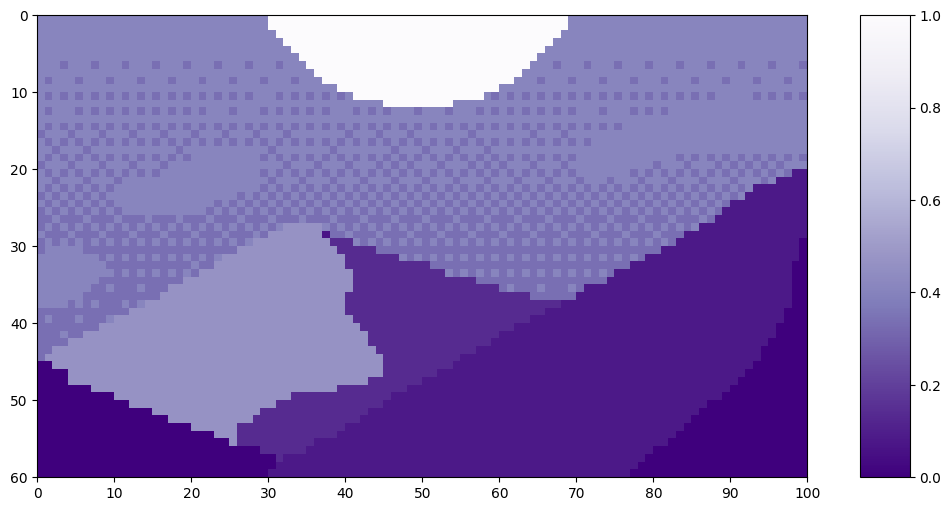

In [12]:
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/lanl/vision_transformers_explained/main/figures/NotebookOutput/mountains.npy"
urllib.request.urlretrieve(url, "mountains.npy")
mountains = np.load("mountains.npy")

H = # Write your code here
W = # Write your code here
print('Mountain at Dusk is H =', H, 'and W =', W, 'pixels.')
print('\n')

fig = plt.figure(figsize=(10,6))
plt.imshow(# Write your code here, cmap='Purples_r')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
# Write your code here
plt.clim([0,1])
cbar_ax = fig.add_axes([0.95, .11, 0.05, 0.77])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax)
#plt.savefig(os.path.join(figure_path, 'mountains.png'), bbox_inches='tight')

Разобъэм это изображение на фрагменты размерности 20. (Более подробно можно прочитать в статье [Vision Transformers article](https://towardsdatascience.com/vision-transformers-explained-a9d07147e4c8).)

There will be 15 patches, each 20 by 20.




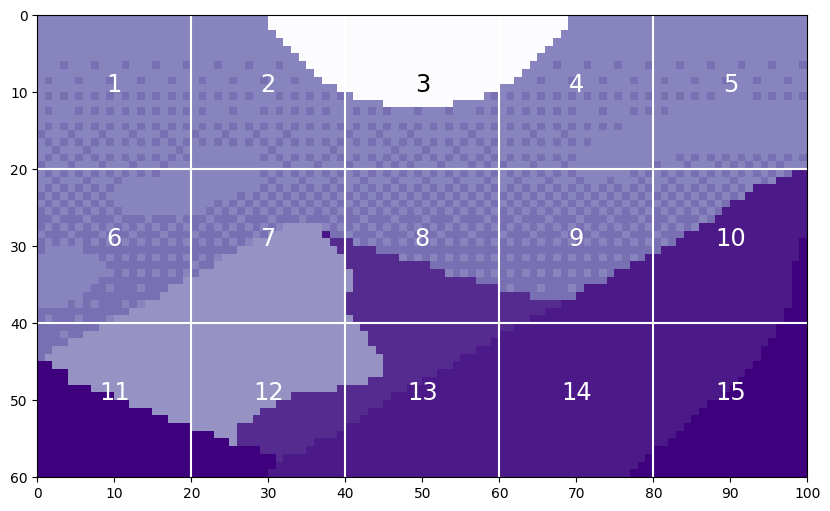

In [13]:
P = 20
N = # Write your code here
print('There will be', # Write your code here, 'patches, each', # Write your code here, 'by', str(P)+'.')
print('\n')

fig = plt.figure(figsize=(10,6))
plt.imshow(# Write your code here, cmap='Purples_r')
plt.clim([0,1])
# Write your code here
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(1, N+1):
    plt.text(x_text[i-1], y_text[i-1], str(i), color='w', fontsize='xx-large', ha='center')
plt.text(x_text[2], y_text[2], str(3), color='k', fontsize='xx-large', ha='center');
#plt.savefig(os.path.join(figure_path, 'mountain_patches.png'), bbox_inches='tight')

Утверждается, что трансформеры, обученные для работы с изображениями (vision transformers),  не смогут отличить исходное изображение от версии, в которой фрагменты были перемешаны.

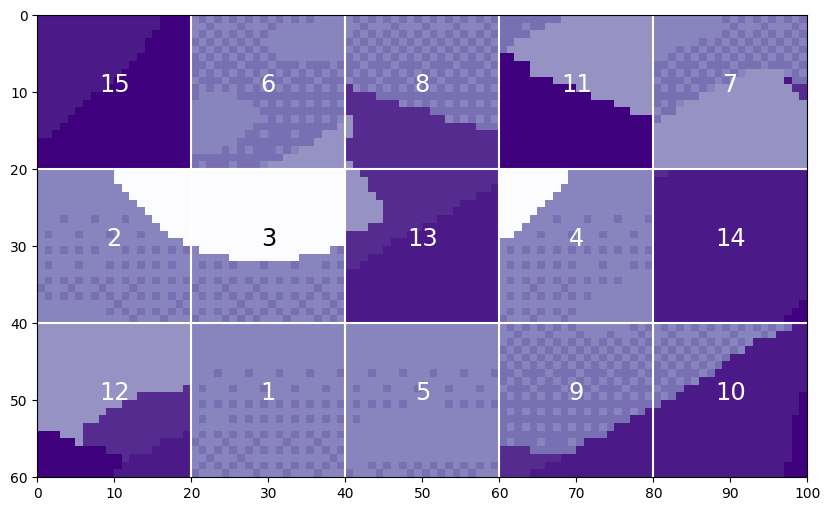

In [14]:
np.random.seed(21)
scramble_order = # Write your code here
left_x = np.tile(np.arange(0, W-P+1, 20), 3)
right_x = np.tile(np.arange(P, W+1, 20), 3)
top_y = np.repeat(np.arange(0, H-P+1, 20), 5)
bottom_y = np.repeat(np.arange(P, H+1, 20), 5)

scramble = # Write your code here
for i in range(N):
    t = # Write your code here
    # Write your code here

fig = plt.figure(figsize=(10,6))
plt.imshow(scramble, cmap='Purples_r')
plt.clim([0,1])
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(N):
    plt.text(x_text[i], y_text[i], str(scramble_order[i]+1), color='w', fontsize='xx-large', ha='center')

i3 = np.where(scramble_order==2)[0][0]
plt.text(x_text[i3], y_text[i3], str(scramble_order[i3]+1), color='k', fontsize='xx-large', ha='center');
#plt.savefig(os.path.join(figure_path, 'mountain_scrambled_patches.png'), bbox_inches='tight')

Очевидно, что получилось отличное от исходного изображение и
Вам бы не хотелось, чтобы трансформер видел эти изображения, как два одинаковых.

# Инвариантность механизма внимания (Attention) к перестановкам

Давайте рассмотрим утверждение о том, что графические трансформеры инвариантны к порядку токенов. Компонентом трансформера, который был бы инвариантен к порядку токенов, является модуль механизма внимания [Attention Article](https://towardsdatascience.com/attention-for-vision-transformers-explained-70f83984c673).

Напомним, что механизм внимания заключается в построении трёх матриц - **Q**ueries (запросов), **K**eys (ключей), и **V**alues (значений) - каждая создаётся в процессе пропускания токена через линейный слой. После формирования матриц Q, K, и V "само внимание" вычисляется по формуле:

$$Attention(Q, K, V) = softmax \biggl(\frac{Q*K^T}{\sqrt{d_k}}\biggr)*V,$$

где $Q$, $K$, $V$ - queries (запросы), keys (ключи) и values (значения), соответственно, а $d_k$ - поправочный множитель.

Чтобы продемонстрировать инвариантность механизма внимания к порядку следования токенов, мы начнём с создания трёх случайно заполненных матриц, которые будут представлять Q, K и V. Размерности матриц Q, K, и V будут следующими:

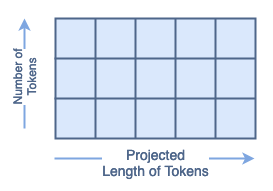

Будем использовать 4 токена с длиной последовательности токенов (projected length), равной 9. Матрицы будут содержать целые числа, чтобы избежать ошибок вычислений чисел с плавающей запятой. После генерации мы поменяем местами токен 0 и токен 2 во всех трех матрицах. Матрицы с поменявшимися местами токенами будут обозначены нижним индексом `s`.

In [15]:
def mat_plot(matrix, title):
    up_clim = max(np.abs(# Write your code here))
    low_clim = # Write your code here
    y, x = # Write your code here
    im = plt.imshow(# Write your code here, cmap='viridis')
    plt.xticks(# Write your code here)
    plt.yticks(# Write your code here)
    plt.title(title)
    plt.vlines(np.arange(0.5, x-0.5, 1), -0.5, y-0.5, colors='#DDDDDD')
    plt.hlines(np.arange(0.5, y-0.5, 1), -0.5, x-0.5, colors='#DDDDDD')

    ## Adding Value Labels
    for i in range(y):
        for j in range(x):
            if # Write your code here: #Don't label if it's zero
                pass
            elif # Write your code here:
                plt.text(j, i, round(matrix[i, j], 2), ha='center', va='center', color='k', fontsize=12)
            else:
                plt.text(j, i, round(matrix[i, j], 2), ha='center', va='center', color='w', fontsize=12)


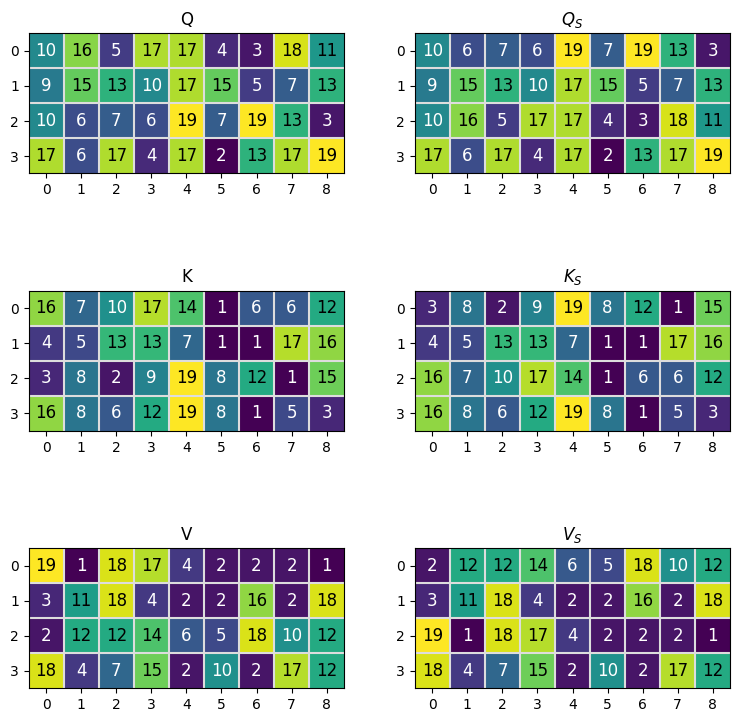

In [16]:
n_tokens = 4
l_tokens = 9
shape = # Write your code here
mx = 20 #max integer for generated matricies

# Generate Normal Matricies
np.random.seed(21)
Q = # Write your code here
K = # Write your code here
V = # Write your code here

# Generate Row-Swapped Matricies
swapQ = copy.deepcopy(Q)
# Write your code here
# Write your code here
# Write your code here
# Write your code here
# Write your code here

# Plot Matricies
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8,8))
fig.tight_layout(pad=2.0)
plt.subplot(3, 2, 1)
mat_plot(Q, 'Q')
plt.subplot(3, 2, 2)
mat_plot(swapQ, r'$Q_S$')
plt.subplot(3, 2, 3)
mat_plot(K, 'K')
plt.subplot(3, 2, 4)
mat_plot(swapK, r'$K_S$')
plt.subplot(3, 2, 5)
mat_plot(V, 'V')
plt.subplot(3, 2, 6)
mat_plot(swapV, r'$V_S$')
#plt.savefig(os.path.join(figure_path, 'randominteger_QKV.png'), bbox_inches='tight')

Первая матричное умножение получается по формуле $Q*K^T=A$, где результирующая матрица $A$  будет квадратной, её размерность будет равна количеству токенов. Когда мы будем вычислять $A_s$ с $Q_s$ и $K_s^T$, результирующая $A_s$ будет иметь измененные позиции строк [0, 2] и столбцов [0,2] в сравнение с матрицей $A$.

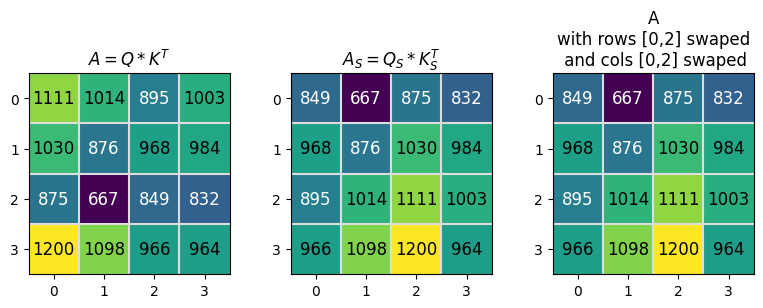

In [17]:
A = # Write your code here
swapA = # Write your code here
modA = copy.deepcopy(# Write your code here)
# Write your code here #swap rows
# Write your code here #swap cols

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8,3))
fig.tight_layout(pad=1.0)
plt.subplot(1, 3, 1)
mat_plot(A, r'$A = Q*K^T$')
plt.subplot(1, 3, 2)
mat_plot(swapA, r'$A_S = Q_S * K_S^T$')
plt.subplot(1, 3, 3)
mat_plot(modA, 'A\nwith rows [0,2] swaped\n and cols [0,2] swaped')
#plt.savefig(os.path.join(figure_path, 'AQKs.png'), bbox_inches='tight')

Cледующее матричное умножение $A*V=A$, где результирующая матрицв $A$ имеет те же размерности, что и первоначальные $Q$, $K$, и $V$ матрицы. Далее мы перемножим $A_s$ с $A_s$ и $V_s$, и результирующая $A_s$ будет иметь строки [0,2] отличными от $A$.

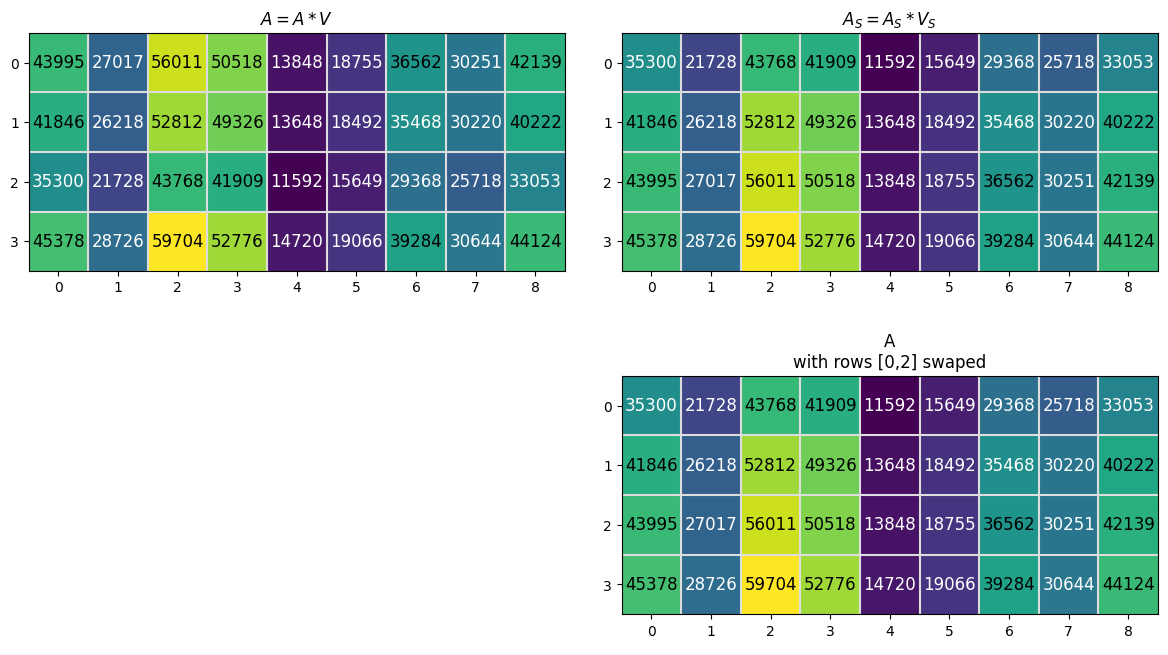

In [18]:
A = # Write your code here
swapA = # Write your code here
modA = copy.deepcopy(# Write your code here)
# Write your code here #swap rows

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))
fig.tight_layout(pad=1.0)
plt.subplot(2, 2, 1)
mat_plot(A, r'$A = A*V$')
plt.subplot(2, 2, 2)
mat_plot(swapA, r'$A_S = A_S * V_S$')
plt.subplot(2, 2, 4)
mat_plot(modA, 'A\nwith rows [0,2] swaped')
axs[1,0].axis('off');
#plt.savefig(os.path.join(figure_path, 'AVAs.png'), bbox_inches='tight')

Это демонстрирует, что изменение порядка токенов на входе слоя внимания приводит к получению выходной матрицы внимания с измененными строками тех же токенов. Это остается интуитивно понятным, поскольку внимание — это вычисление взаимосвязи между токенами. Без информации о положении изменение порядка токенов не меняет того, как они связаны. Автор статьи отмечает неочевидность, почему такой перестановки выходных данных недостаточно для передачи информации о положении трансформерам. Однако все источники, говорят о том, что этого недостаточно, поэтому мы принимаем это как факт и двигаемся дальше.

# Позиционные эмбеддинги в литературе

Помимо теоретического обоснования использования позиционных эмбеддингов, модели, их использующие, демонстрируют более высокую точность, чем модели без них. Однако нет четких доказательств в пользу одного типа позиционных эмбеддингов по сравнению с другим.

В статье "Attention is All You Need" авторы используют фиксированное синусоидальное позиционное кодиродвание. Они отмечают, что экспериментировали с обученным позиционным эмбеддингом, но наблюдали «практически идентичные результаты». Следует отметить, что эта модель была разработана для приложений обработки естественного языка, в частности, для перевода. Авторы использовали фиксированные эмбеддинги, поскольку онм позволяло изменять длину фраз. В приложениях компьютерного зрения это, вероятно, не было бы проблемой.

В статье "An Image is Worth 16x16 Words" авторы применяют позиционные эмбеддинги к изображениям. Они проводят исследования с использованием четырех различных позиционных эмбеддингов как в фиксированном, так и в обучаемом режимах. В этом исследовании рассматриваются модели без встраивания позиций, модели с одномерным встраиванием позиций, модели с двумерным встраиванием позиций и модели с относительным встраиванием позиций. Авторы обнаружили, что модели с встраиванием позиций значительно превосходят модели без встраивания позиций. Однако между различными типами встраивания позиций или между фиксированным и обучаемым встраиванием позиций существует небольшая разница. Это согласуется с результатами [1], где показано, что встраивание позиций является полезным, хотя точный выбранный тип встраивания имеет небольшое значение.

В работе "Tokens-to-Token ViT: Training Vision Transformers from Scratch on ImageNet" они используют синусоидальное встраивание позиций, которое, по их описанию, идентично тому, что используется в [2]. Опубликованный ими код повторяет уравнения для синусоидального встраивания позиций из [1]. Кроме того, в опубликованном коде встраивание позиций фиксируется, а не становится обучаемым параметром с синусоидальной инициализацией.

# Пример Position Embedding

## Определение позиционного встраивания (Position Embedding)

Теперь рассмотрим особенности синусоидального встраивания позиции. Код основан на общедоступном коде GitHub для "Tokens-to-Token ViT". Функционально встраивание позиции представляет собой матрицу той же формы, что и токены. Это выглядит так:

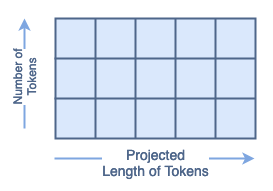

Формула синусоидального позиционного встраивания (sinusoidal position embedding) из работы [1] выглядит примерно так

$$\theta_{ij} = \frac{i}{10,000^{2jd^{-1}}}$$

$$PE_{(i, 2j)} = sin(\theta_{ij})$$

$$PE_{(i, 2j+1)} = cos(\theta_{ij})$$

где $PE$ - матрица позиционных эмбеддингов, $i$ - количество токенов, $j$ - длины токенов, и $d$ - длина одного токена.

В коде это выглядит следующим образом:

In [19]:
def get_sinusoid_encoding(num_tokens, token_len):
    """ Make Sinusoid Encoding Table

        Args:
            num_tokens (int): number of tokens
            token_len (int): length of a token

        Returns:
            (torch.FloatTensor) sinusoidal position encoding table
    """

    def get_position_angle_vec(i):
        return # Write your code here

    sinusoid_table = np.array([get_position_angle_vec(i) for i in range(num_tokens)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

Попробуем сгенерировать пример матрицы позиционных эмбеддингов. Будем использовать 176 токеноа, каждый длины 768, что взято из кода T2T-ViT. Отобразим матрицу графически.

In [20]:
PE = # Write your code here

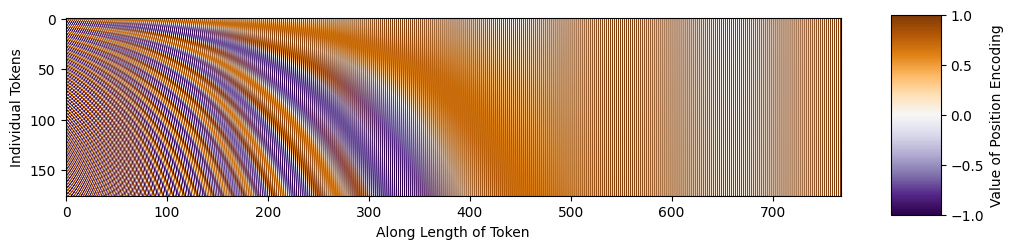

In [21]:
fig = plt.figure(figsize=(10, 8))
plt.imshow(PE[0, :, :], cmap='PuOr_r')
plt.xlabel('Along Length of Token')
plt.ylabel('Individual Tokens');
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([-1, 1])
plt.colorbar(label='Value of Position Encoding', cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'fullPE.png'), bbox_inches='tight')

Приблизим начало токенов.

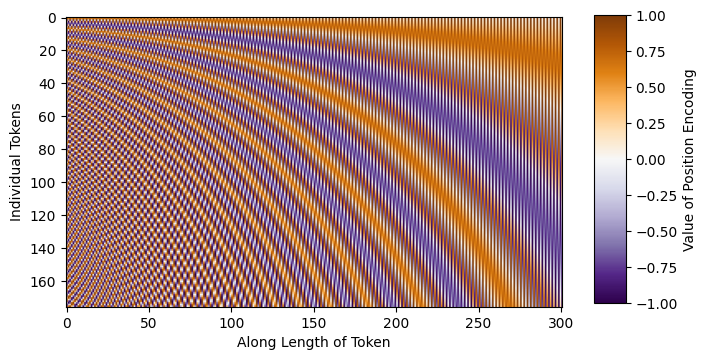

In [22]:
fig = plt.figure()
plt.imshow(PE[0, :, 0:301], cmap='PuOr_r')
plt.xlabel('Along Length of Token')
plt.ylabel('Individual Tokens');
cbar_ax = fig.add_axes([0.95, .2, 0.05, 0.6])
plt.clim([-1, 1])
plt.colorbar(label='Value of Position Encoding', cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'zoomedinPE.png'), bbox_inches='tight')

У неё действительно синусоидальная структура!

# Применение позиционного кодирования для токенов

Теперь мы можем добавить позиционное кодирование к нашим токенам, будем использовать Mountain at Dusk с той же токенизацией, что и выше. Это даст нам 15 токенов длины $20^2=400$. Более подробно о токенизации фрагментов картинок можно почитать в статье [Vision Transformers article](https://towardsdatascience.com/vision-transformers-explained-a9d07147e4c8).

Напомним, что в нашем случае фрагментация выглядит следующим образом:

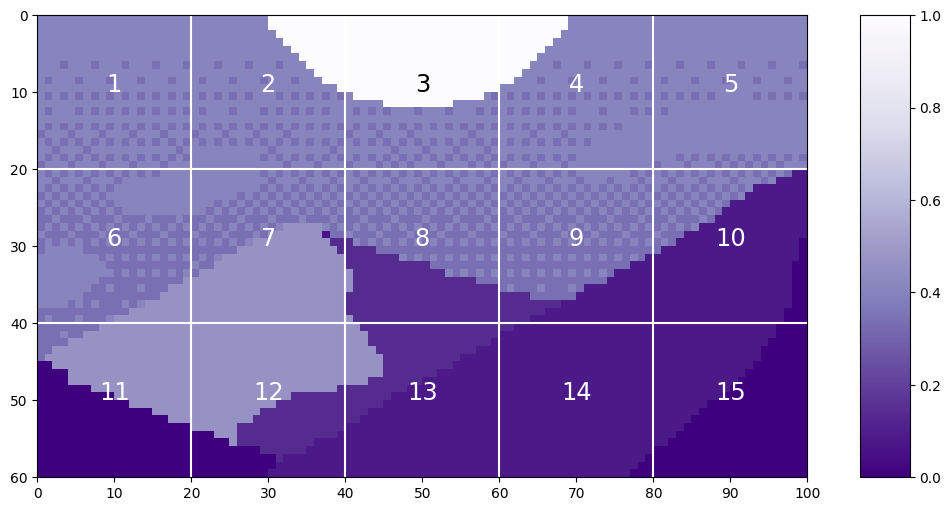

In [23]:
fig = plt.figure(figsize=(10,6))
plt.imshow(# Write your code here, cmap='Purples_r')
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(1, N+1):
    plt.text(x_text[i-1], y_text[i-1], str(i), color='w', fontsize='xx-large', ha='center')
plt.text(x_text[2], y_text[2], str(3), color='k', fontsize='xx-large', ha='center')
cbar_ax = fig.add_axes([0.95, .11, 0.05, 0.77])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountain_patches_w_colorbar.png'), bbox_inches='tight')

Если перевести фрагменты в токены, это будет выглядеть следующим образом:

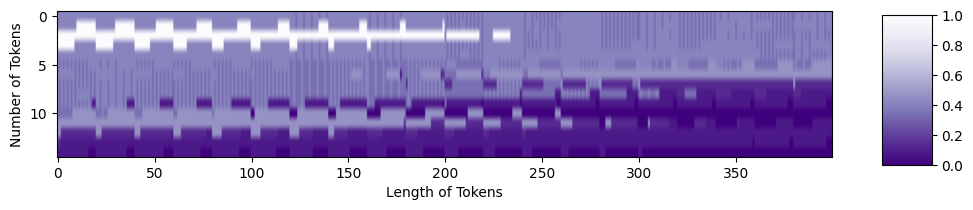

In [24]:
patch = # Write your code here
tokens = # Write your code here
for i in range(N):
    patch = # Write your code here
    # Write your code here

fig = plt.figure(figsize=(10,6))
plt.imshow(tokens, aspect=5, cmap='Purples_r')
plt.xlabel('Length of Tokens')
plt.ylabel('Number of Tokens')
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountain_tokens_matrix.png'), bbox_inches='tight')

Теперь можно посмортеть на позиционное кодироване в правильной размерности:

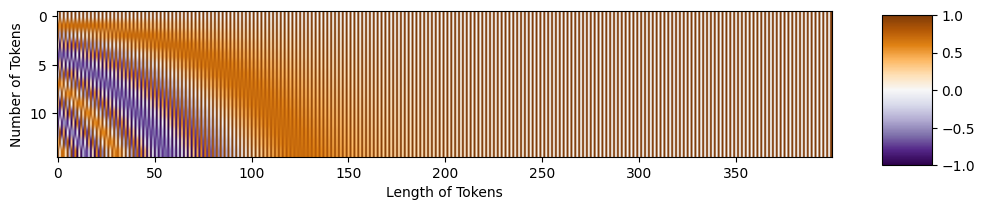

In [25]:
PE = # Write your code here(num_tokens=15, token_len=400).numpy()[0,:,:]
fig = plt.figure(figsize=(10,6))
plt.imshow(PE, aspect=5, cmap='PuOr_r')
plt.xlabel('Length of Tokens')
plt.ylabel('Number of Tokens')
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([-1, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountainsPE.png'), bbox_inches='tight')

Теперь мы готовы добавить встраивание позиции к токенам. Фиолетовые области в позиционно кодировании сделают токены темнее, а оранжевые — светлее.

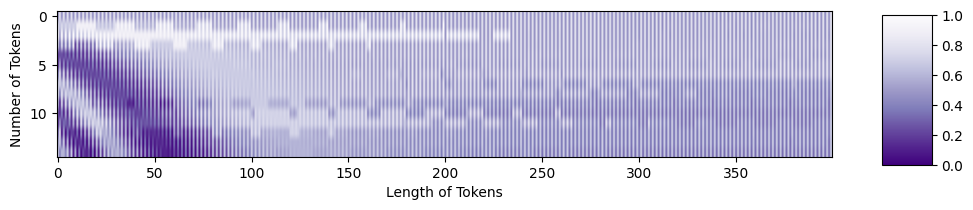

In [26]:
mountainsPE = # Write your code here
rescaled_mountainsPE = # Write your code here

fig = plt.figure(figsize=(10,6))
plt.imshow(rescaled_mountainsPE, aspect=5, cmap='Purples_r')
plt.xlabel('Length of Tokens')
plt.ylabel('Number of Tokens')
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountains_plus_PE.png'), bbox_inches='tight')

Вы можете увидеть структуру исходных токенов, а также структуру вложенной позиции! Оба фрагмента информации присутствуют и могут быть переданы в преобразователь.

# Заключение

Теперь у вас должно быть некоторое представление о том, как позиционные эмбеддинги помогают трансформерам в машинном обучении. Код, связанный с этой статьей, можно найти в [репозитории Github](https://github.com/lanl/vision_transformers_explained) для этой серии. Код из статьи T2T-ViT можно найти [здесь](https://github.com/yitu-opensource/T2T-ViT). Удачных преобразований!

Эта статья была одобрена для публикации Национальной лабораторией Лос-Аламоса под номером LA-UR-23–33876. Соответствующий код был одобрен для использования под лицензией BSD-3 с открытым исходным кодом O#4693.

# Для более глубокого изучения

Задачи обработки естесвенного языка:
 - A Gentle Introduction to Positional Encoding in Transformer Models: https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/

Задачи компьютерного зрения:
 - Vision Transformer and its Applications: https://youtu.be/hPb6A92LROc?si=GaGYiZoyDg0PcdSP
      - Vision Transformer is Invariant to Position of Patches 10:44–12:52 (https://youtu.be/hPb6A92LROc?t=644&si=Keu-5i9BQ5c69mxz)
      - Position Embedding 12:52–14:15 (https://youtu.be/hPb6A92LROc?t=772&si=spdlYZl-TRgbGgzn)

# Используемая литература

[1] Vaswani et al (2017). Attention Is All You Need. https://doi.org/10.48550/arXiv.1706.03762

[2] Dosovitskiy et al (2020). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. https://doi.org/10.48550/arXiv.2010.11929

[3] Luis Zuno (@ansimuz). Mountain at Dusk Background. License CC0: https://opengameart.org/content/mountain-at-dusk-background

[4] Yuan et al (2021). Tokens-to-Token ViT: Training Vision Transformers from Scratch on ImageNet. https://doi.org/10.48550/arXiv.2101.11986
 - GitHub code: https://github.com/yitu-opensource/T2T-ViT